# Figure 5 iMN graphics (6-well)

Notes:

1. Only singlets
2. Reseed at 7 dpi with puro, with full media changes until 1/2 media X on days 11, 12, 13, flow on 14 (7 days with puro)

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
from matplotlib.patches import Patch
import statsmodels
import pyarrow
import fastparquet
import openpyxl

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

# Load in data

7 dpi flow data

In [2]:
# figure path
output_path_Figure5 = rd.rootdir/'output'/'Figure_5'
output_path_FigureS9 = rd.rootdir/'output'/'Figure_S9'

In [3]:
# Base dir for data files
path = rd.datadir /'data'/'attune'/ 'nat_attune' / 'desNb-circuits' / "2025.11.26_DASIT-iMN-purify_1-3"

# Data path
cache_path_7dpi = rd.rootdir/'output'/'Figure_5'/'data.gzip'

if cache_path_7dpi.exists():
    df_7dpi = pd.read_parquet(cache_path_7dpi)

else: 
    
    files = Path(path / 'export_singlets_7dpi').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        print(file.name)

        match = re.search('export_(?P<cond>.+)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')

        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        if cond == 'Ctrl-neg':
            rep = 0
        elif cond[:3] == 'rep':
            rep = int(cond[3])
            cond = 'main'
            
        df['dpi'] = 7
        df['cond'] = cond
        df['rep'] = rep

        df_list.append(df)

    # Convert list of dfs into single df
    df_7dpi = pd.concat(df_list, ignore_index=True)

    # Shorten df
    channel_list = ['eGFP-H', 'dpi', 'cond', 'rep']
    df_7dpi = df_7dpi.loc[:, channel_list]

    # Save shortened df
    df_7dpi.to_parquet(rd.outfile(cache_path_7dpi))

export_Ctrl-neg_Singlets.csv
export_rep1_Singlets.csv
export_rep2_Singlets.csv
export_rep3_Singlets.csv


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

Hemocytometer data

In [4]:
df_counts_7dpi = pd.read_excel(open(path/'2025.11.26_counts.xlsx', 'rb'), sheet_name='7 dpi summary') 

# Add in how many HG cells per 6well there is using hemocytometer data
for index, row in df_counts_7dpi.iterrows():

    df_counts_7dpi.loc[index, 'percent Hb9::EGFP+'] = row['Hb9::EGFP+ [frac]']*100
    df_counts_7dpi.loc[index, 'Cells per 6well'] = row['Cells per 6well [mil]']*1e6
    df_counts_7dpi.loc[index, 'HG cells per 6well [mil]'] = row['Cells per 6well [mil]']*row['Hb9::EGFP+ [frac]']

df_counts_7dpi

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

# 7 dpi, reseeding data

From 2025.11.26_DASIT-iMN-purify_1-3 >> 2025.11.26_7dpi_count.xlsx

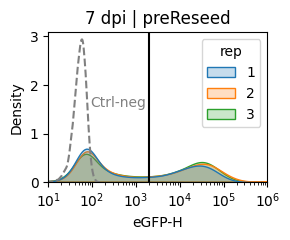

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

# Threshold for Hb9::GFP
# eGFP_H_thresh = 5e3
eGFP_H_thresh = 2e3
hue = 'rep'
palette = 'tab10'

# Plot eGFP-H
x = 'eGFP-H'
sns.kdeplot(data=df_7dpi.loc[(df_7dpi['cond'] != 'Ctrl-neg') & (df_7dpi[x]>0)], # (df_7dpi['rep'] == 1) & 
        ax=ax, x=x, hue=hue,
        common_norm=False, log_scale=(True, False), palette=palette,
        fill=True)


# Plot ctrl-neg
sns.kdeplot(data=df_7dpi.loc[(df_7dpi['cond'] == 'Ctrl-neg') & (df_7dpi[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.32, 0.5), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'7 dpi | preReseed')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'dist-eGFP_7dpi.svg', bbox_inches='tight')

Make new df that is split by cell type (HG+ vs. all) for plotting purposes

In [5]:
# Make a new df split by cell type for plotting
df_counts_7dpi_HG = df_counts_7dpi.copy()
df_counts_7dpi_HG.loc[:, 'cellType'] = 'EGFP+'
df_counts_7dpi_all = df_counts_7dpi.copy()
df_counts_7dpi_all.loc[:, 'cellType'] = 'All'

df_counts_7dpi_split = pd.concat([df_counts_7dpi_all, df_counts_7dpi_HG], ignore_index=True)
df_counts_7dpi_split

# Merge wih data from counts
for index, row in df_counts_7dpi_split.iterrows():
    if row['cellType'] == 'EGFP+':
        df_counts_7dpi_split.loc[index, 'Cells per 6well [mil]'] = row['Cells per 6well [mil]']*row['Hb9::EGFP+ [frac]']

df_counts_7dpi_split.loc[:, 'Cells per 6well'] = df_counts_7dpi_split.loc[:, 'Cells per 6well [mil]']*1e6 

df_counts_7dpi_split

,dpi,rep,cond,purifyCond,Total 6wells dissociated,Cells per 6well [mil],Hb9::EGFP+ [frac],percent Hb9::EGFP+,Cells per 6well,HG cells per 6well [mil],cellType
0,7,1,main,preReseed,6,3.216667,0.42,42.0,3.216667e+06,1.351000,All
1,7,2,main,preReseed,6,2.900000,0.46,46.0,2.900000e+06,1.334000,All
2,7,3,main,preReseed,6,2.316667,0.47,47.0,2.316667e+06,1.088833,All
3,7,1,main,preReseed,6,1.351000,0.42,42.0,1.351000e+06,1.351000,EGFP+
4,7,2,main,preReseed,6,1.334000,0.46,46.0,1.334000e+06,1.334000,EGFP+
5,7,3,main,preReseed,6,1.088833,0.47,47.0,1.088833e+06,1.088833,EGFP+


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\2418276099.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\2418276099.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, '(#) Cells per 6-well\n(75k seed)')

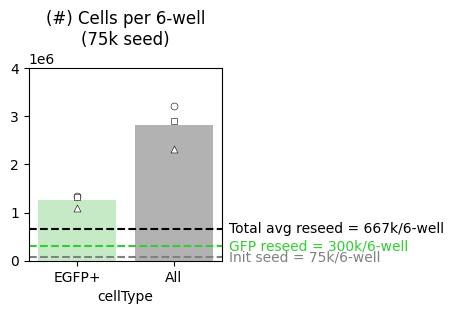

In [6]:
# General plotting params
x = 'cellType'
y = 'Cells per 6well'
order = ['EGFP+', 'All']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

palette = {'All': 'black', 'EGFP+': 'limegreen'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))

sns.barplot(
    ax=ax, data=df_counts_7dpi_split, 
    x=x, y=y, 
    order=order,
    ci=None,
    palette=palette, alpha=0.3)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_7dpi_split.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_7dpi_split[(df_counts_7dpi_split.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

ax.yaxis.set_label_text('')
ax.set_ylim([0, 3.5e6])
ax.set_yticks(np.arange(0, 4e6+1, 1e6))

# Annotate lines
init_seed = 75e3 # 75k MEFs/6-well init seed
GFP_reseed = 0.3e6 # 300k Hb9::EGFP+/6-well reseed at 7 dpi
frac_EGFP = df_counts_7dpi.loc[:,'Hb9::EGFP+ [frac]'].mean()
total_reseed = GFP_reseed/frac_EGFP # How many total cells/6-well reseed at 7 dpi
init_seed_color = 'grey'
GFP_reseed_color = 'limegreen'
total_reseed_color = 'black'
ax.axhline(init_seed, 0, 1, color=init_seed_color, linestyle='--')
ax.axhline(GFP_reseed, 0, 1, color=GFP_reseed_color, linestyle='--')
ax.axhline(total_reseed, 0, 1, color=total_reseed_color, linestyle='--')

ax.annotate(f'Init seed = {init_seed/1e3:.0f}k/6-well', 
            xy=(1, init_seed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=init_seed_color, verticalalignment='center', horizontalalignment='left')
ax.annotate(f'GFP reseed = {GFP_reseed/1e3:.0f}k/6-well', 
            xy=(1, GFP_reseed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=GFP_reseed_color, verticalalignment='center', horizontalalignment='left')
ax.annotate(f'Total avg reseed = {total_reseed/1e3:.0f}k/6-well',
            xy=(1, total_reseed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=total_reseed_color, verticalalignment='center', horizontalalignment='left')

# h,l = ax1.get_legend_handles_labels()
# sns.move_legend(ax1, title='Seed by cond', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


plt.title('(#) Cells per 6-well\n(75k seed)')
# plt.savefig(figpath + f'7dpi_cellcounts.svg', bbox_inches='tight')

In [7]:
df_counts_7dpi

,dpi,rep,cond,purifyCond,Total 6wells dissociated,Cells per 6well [mil],Hb9::EGFP+ [frac],percent Hb9::EGFP+,Cells per 6well,HG cells per 6well [mil]
0,7,1,main,preReseed,6,3.216667,0.42,42.0,3.216667e+06,1.351000
1,7,2,main,preReseed,6,2.900000,0.46,46.0,2.900000e+06,1.334000
2,7,3,main,preReseed,6,2.316667,0.47,47.0,2.316667e+06,1.088833


Text(0.5, 0.98, '7 dpi')

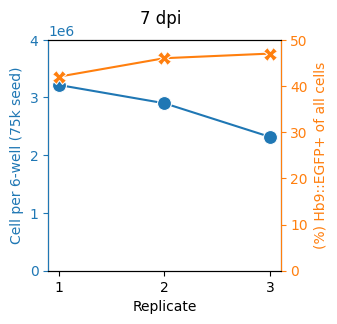

In [8]:
# General plotting params
x = 'rep'

# Plot
fig, ax1 = plt.subplots(1, 1, figsize=(3,3))

y1 = 'Cells per 6well'
color1 = 'tab:blue'
sns.lineplot(
    ax=ax1, data=df_counts_7dpi,
    x=x, y=y1,
    marker='o', markersize=10, color=color1)

y2 = 'percent Hb9::EGFP+'
color2 = 'tab:orange'
ax2 = ax1.twinx()
sns.lineplot(
    ax=ax2, data=df_counts_7dpi,
    x=x, y=y2,
    marker='X', markersize=10, color=color2, legend=False)

ax1.yaxis.set_label_text('Cell per 6-well (75k seed)', color=color1)
ax1.tick_params(axis='y', colors=color1)
# ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1e6:.0f}e6'))
ax1.set_yticks(np.arange(0, 4.1e6, 1e6))
ax1.set_ylim([0, 4e6])

ax2.yaxis.set_label_text('(%) Hb9::EGFP+ of all cells', color=color2)
ax2.tick_params(axis='y', colors=color2)

ax2.spines['left'].set_color(color1)
ax2.spines['right'].set_color(color2)
ax2.set_ylim([0, 50])

ax1.set_xticks(np.arange(1, 4, 1))
ax1.set_xlabel('Replicate')

plt.suptitle(f'7 dpi')

# Post-selection

## Load data

In [9]:
# Base dir for data files
path = rd.datadir /'data'/'attune'/ 'nat_attune' / 'desNb-circuits' / "2025.11.26_DASIT-iMN-purify_1-3"

# Data path
cache_path_14dpi = rd.rootdir/'output' /'Figure_5'/'data_14dpi.gzip'

if cache_path_14dpi.exists():
    df_14dpi = pd.read_parquet(cache_path_14dpi)

else: 
    
    files = Path(path / 'export_singlets_14dpi').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        match = re.search('export_(?P<cond>.+)_(?P<purify>.+)_(?P<rep>\d)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')
        purify = match.group('purify')
        rep = match.group('rep')

        if purify[:4] == 'puro':
            puro = float(purify[4:])
            cond = "postPuro"
        else:
            puro = 0

        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        df['dpi'] = 14
        df['cond'] = cond
        df['purify'] = purify
        df['rep'] = int(rep)
        
        df_list.append(df)

    # Convert list of dfs into single df
    df_14dpi = pd.concat(df_list, ignore_index=True)

    # # Convert puro to int
    # df_all = df_all.astype({'puro': 'int'})

    # Shorten df
    channel_list = ['eGFP-H', 'dpi', 'cond', 'purify', 'rep']
    df_14dpi = df_14dpi.loc[:, channel_list]

    # Save shortened df
    df_14dpi.to_parquet(rd.outfile(cache_path_14dpi))

<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\618070879.py:17: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('export_(?P<cond>.+)_(?P<purify>.+)_(?P<rep>\d)_Singlets.csv', file.name)


In [10]:
display(df_14dpi)

,eGFP-H,dpi,cond,purify,rep
0,78,14,Ctrl-neg,Ctrl-neg,1
1,27,14,Ctrl-neg,Ctrl-neg,1
2,73,14,Ctrl-neg,Ctrl-neg,1
3,63,14,Ctrl-neg,Ctrl-neg,1
4,98,14,Ctrl-neg,Ctrl-neg,1
...,...,...,...,...,...
188776,448,14,noReseed,preFACS,3
188777,88,14,noReseed,preFACS,3
188778,97,14,noReseed,preFACS,3
188779,126,14,noReseed,preFACS,3


Hemocytometer data

In [1]:
df_counts_14dpi = pd.read_excel(open(path/'2025.11.26_counts.xlsx', 'rb'), sheet_name='14 dpi summary') 

# Add in how many HG cells per 6well there is using hemocytometer data
for index, row in df_counts_14dpi.iterrows():

    df_counts_14dpi.loc[index, 'cond.purifyCond'] = row['cond'] + "." + row['purifyCond']
    df_counts_14dpi.loc[index, 'Hb9::EGFP+ [%]'] = row['Hb9::EGFP+ [frac]']*100
    df_counts_14dpi.loc[index, 'Total # cells'] = row['Total # cells [k]']*1e3
    df_counts_14dpi.loc[index, 'Cells per 6well'] = df_counts_14dpi.loc[index, 'Total # cells']/row['Total 6wells dissociated']
    df_counts_14dpi.loc[index, 'HG cells per 6well'] = df_counts_14dpi.loc[index, 'Cells per 6well']*row['Hb9::EGFP+ [frac]']
    df_counts_14dpi.loc[index, 'Hb9::EGFP+ recovery [%]'] = row['Hb9::EGFP+ recovery [%]']

df_counts_14dpi

NameError: name 'pd' is not defined

## Look at iMN purity without reseed

### eGFP threshold and distribution

In [37]:
df_14dpi.cond.unique()

array(['Ctrl-neg', 'postPuro', 'noReseed'], dtype=object)

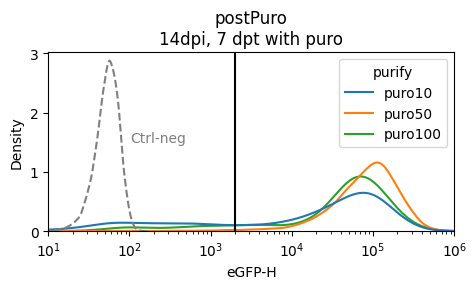

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Threshold for Hb9::GFP
# eGFP_H_thresh = 5e3
eGFP_H_thresh = 2e3

# Plot eGFP-H
x = 'eGFP-H'
cond = 'postPuro'
hue = 'purify'
hue_order = ['puro10', 'puro50', 'puro100']
rep = 1
sns.kdeplot(data=df_14dpi.loc[(df_14dpi['cond'] == cond) & (df_14dpi[x]>0) & (df_14dpi['rep']==rep)],
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=False)


# Plot ctrl-neg
sns.kdeplot(data=df_14dpi.loc[(df_14dpi['cond'] == 'Ctrl-neg') & (df_14dpi[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.27, 0.5), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'{cond}\n14dpi, 7 dpt with puro')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + f'dist-eGFP_14dpi_{cond}_{rep}.svg', bbox_inches='tight')

In [39]:
# Categorize iMNs based on eGFP_thresh
df_14dpi['eGFP_cat'] = np.where(df_14dpi['eGFP-H'] > eGFP_H_thresh, 'iMN', 'fib') 

# Get total counts and percent of GFP-H+
group = ['dpi', 'cond', 'purify']
count_df_reps = df_14dpi.groupby([*group, 'rep', 'eGFP_cat'])[
    'eGFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
data_iMN_percent_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'rep']).transform('sum')).reset_index(name='percent')

# Extract just the iMNs
data_iMN_percent_reps = data_iMN_percent_reps.loc[(data_iMN_percent_reps['eGFP_cat'] == 'iMN')]

In [40]:
data_iMN_percent_reps[data_iMN_percent_reps.rep == 1]

,dpi,cond,purify,rep,eGFP_cat,percent
1,14,Ctrl-neg,Ctrl-neg,1,iMN,0.000000
3,14,noReseed,postFACS,1,iMN,87.078533
9,14,noReseed,preFACS,1,iMN,42.722022
15,14,postPuro,puro10,1,iMN,70.469507
21,14,postPuro,puro100,1,iMN,88.180404
27,14,postPuro,puro50,1,iMN,98.889461


## Purity

In [41]:
df_counts_14dpi

,dpi,rep,cond,purifyCond,Total 6wells dissociated,Total # cells [k],Hb9::EGFP+ [frac],Unnamed: 7,cond.purifyCond,Hb9::EGFP+ [%],Total # cells,Cells per 6well,HG cells per 6well
0,14,1,DASIT,puro0,2,1100.000000,0.35,NaN,DASIT.puro0,35.0,1.100000e+06,5.500000e+05,192500.0
1,14,1,DASIT,puro10,1,195.000000,0.70,NaN,DASIT.puro10,70.0,1.950000e+05,1.950000e+05,136500.0
2,14,1,DASIT,puro50,2,316.666667,0.99,NaN,DASIT.puro50,99.0,3.166667e+05,1.583333e+05,156750.0
3,14,1,DASIT,puro100,1,2.500000,0.88,NaN,DASIT.puro100,88.0,2.500000e+03,2.500000e+03,2200.0
4,14,1,noReseed,preFACS,1,3287.500000,0.41,NaN,noReseed.preFACS,41.0,3.287500e+06,3.287500e+06,1347875.0
5,14,2,DASIT,puro0,2,925.000000,0.30,NaN,DASIT.puro0,30.0,9.250000e+05,4.625000e+05,138750.0
6,14,2,DASIT,puro10,1,92.500000,0.77,NaN,DASIT.puro10,77.0,9.250000e+04,9.250000e+04,71225.0
7,14,2,DASIT,puro50,2,225.000000,0.99,NaN,DASIT.puro50,99.0,2.250000e+05,1.125000e+05,111375.0
8,14,2,DASIT,puro100,1,5.000000,0.89,NaN,DASIT.puro100,89.0,5.000000e+03,5.000000e+03,4450.0
9,14,2,noReseed,preFACS,1,2112.500000,0.38,NaN,noReseed.preFACS,38.0,2.112500e+06,2.112500e+06,802750.0


**Figure 5D - iMN purity**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\3487866209.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


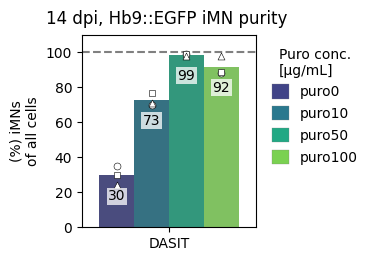

In [75]:
# General plotting params
x = 'cond'
y = 'Hb9::EGFP+ [%]'
order = ['DASIT']
hue = 'purifyCond'
hue_order = ['puro0', 'puro10', 'puro50', 'puro100']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = 'viridis'

label_dict = {'puro0':'0', 'puro10':'10', 'puro50':'50', 'puro100':'100'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)
    

# # Add in stats
# # Pairs for stats comp
# pairs = [(('DASIT', 'puro0'), ('DASIT', 'puro50'))]
# annot = Annotator(ax=ax,
#     data=df_counts_14dpi, pairs=pairs,
#     x=x, y=y, hue=hue,
#     order=order, hue_order=hue_order)
# annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
# annot.apply_test().annotate(line_offset_to_group=0.05)

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='grey', label=str(puro), linewidth=0.2)
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n[µg/mL]',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))   

# Formatting
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
# # ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN purity')
plottitle = f'Figure_5D_iMN_bar_purity.svg'
plt.savefig(rd.outfile(output_path_Figure5/plottitle),bbox_inches='tight')     

**Figure S9D - iMN Purity**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\1552431106.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


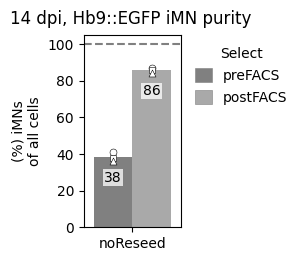

In [76]:
# General plotting params
x = 'cond'
y = 'Hb9::EGFP+ [%]'
order = ['noReseed']
hue = 'purifyCond'
hue_order = ['preFACS', 'noReseed-postFACS']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = {'preFACS':'grey', 'noReseed-postFACS':'darkgray'}

label_dict = {'preFACS':'preFACS', 'noReseed-postFACS':'postFACS'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# legend
legend_elements = [
    Patch(facecolor='grey', edgecolor='grey', linewidth=0.4,
          label='preFACS'),
    Patch(facecolor='darkgray', edgecolor='grey', linewidth=0.4,
          label='postFACS')
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_elements,
    title='Select',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))   

# Formatting
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
# # ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 105])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN purity')
plottitle = f'Figure_S9D_iMN_bar_purity.svg'
plt.savefig(rd.outfile(output_path_FigureS9/plottitle),bbox_inches='tight')   

**Figure 5F - iMN Purity**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\621361706.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\621361706.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\621361706.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_dict[l] for l in order])


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

noReseed.noReseed-postFACS vs. DASIT.puro50: t-test independent samples with Bonferroni correction, P_val:1.603e-04 t=-1.379e+01


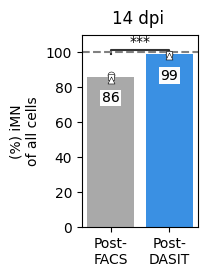

In [77]:
# General plotting params
x = 'cond.purifyCond'
y = 'Hb9::EGFP+ [%]'
order = ['noReseed.noReseed-postFACS', 'DASIT.puro50']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

label_dict = {'DASIT.puro50':'Post-\nDASIT', 'noReseed.noReseed-postFACS':'Post-\nFACS'}

palette = {'DASIT.puro50':'dodgerblue', 'noReseed.noReseed-postFACS':'darkgray'}


# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.5,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y,
    ci=None,
    order=order,
    palette=palette,
    alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

# Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
                

ax.set_xticklabels([label_dict[l] for l in order])

# Add in stats
# Pairs for stats comp
pairs = [('DASIT.puro50', 'noReseed.noReseed-postFACS')]
annot = Annotator(ax=ax,
    data=df_counts_14dpi, pairs=pairs,
    x=x, y=y,
    order=order)
annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
annot.apply_test().annotate(line_offset_to_group=0)


# Formatting
ax.yaxis.set_label_text('(%) iMN\nof all cells')
ax.xaxis.set_label_text('')
ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi')
plottitle = f'Figure_5F_iMN_bar_purity_POST.svg'
plt.savefig(rd.outfile(output_path_Figure5/plottitle),bbox_inches='tight')   

## Count

**Figure 5D - iMN Count**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\1898275279.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


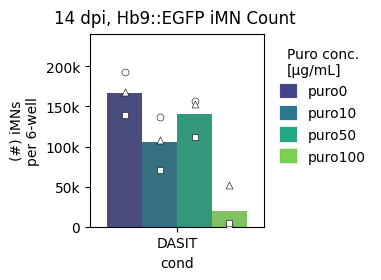

In [78]:
# General plotting params
x = 'cond'
y = 'HG cells per 6well'
order = ['DASIT']
hue = 'purifyCond'
hue_order = ['puro0', 'puro10', 'puro50', 'puro100']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = 'viridis'

label_dict = {'puro0':'0', 'puro10':'10', 'puro50':'50', 'puro100':'100'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='grey', label=str(puro), linewidth=0.2)
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n[µg/mL]',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
 

# Formatting
ax.yaxis.set_label_text('(#) iMNs\nper 6-well')
# ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 240e3])


# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN Count')
plottitle = f'Figure_5D_iMN_bar_count.svg'
plt.savefig(rd.outfile(output_path_Figure5/plottitle),bbox_inches='tight')   

**Figure S9D - iMN Count**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\2190314571.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


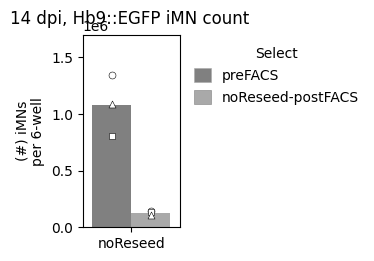

In [79]:
# General plotting params
x = 'cond'
y = 'HG cells per 6well'
order = ['noReseed']
hue = 'purifyCond'
hue_order = ['preFACS', 'noReseed-postFACS']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = {'preFACS':'grey', 'noReseed-postFACS':'darkgray'}

label_dict = {'preFACS':'preFACS', 'noReseed-postFACS':'postFACS'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# legend
legend_elements = [
    Patch(facecolor='grey', edgecolor='darkgrey', linewidth=0.4,
          label='preFACS'),
    Patch(facecolor='darkgray', edgecolor='grey', linewidth=0.4,
          label='noReseed-postFACS')
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_elements,
    title='Select',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
 

# Formatting
ax.yaxis.set_label_text('(#) iMNs\nper 6-well')
ax.xaxis.set_label_text('')
# ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 1.7e6])


# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN count')
plottitle = f'Figure_S9D_iMN_bar_count_FACS.svg'
plt.savefig(rd.outfile(output_path_FigureS9/plottitle),bbox_inches='tight')   

**Figure 5G - iMN Recovery - NEEDS TO BE FIXED**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_27644\2888584416.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


ValueError: Could not interpret value `Hb9::EGFP+ recovery [%]` for `y`. An entry with this name does not appear in `data`.

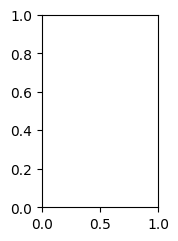

In [ ]:
# General plotting params
x = 'cond.purifyCond'
y = 'Hb9::EGFP+ recovery [%]'
order = ['noReseed.noReseed-postFACS', 'DASIT.puro50']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

label_dict = {'DASIT.puro50':'Post-\nDASIT', 'noReseed.noReseed-postFACS':'Post-\nFACS'}

palette = {'DASIT.puro50':'dodgerblue', 'noReseed.noReseed-postFACS':'darkgray'}


# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.5,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y,
    ci=None,
    order=order,
    palette=palette,
    alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

# Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
                

ax.set_xticklabels([label_dict[l] for l in order])

# Add in stats
# Pairs for stats comp
pairs = [('DASIT.puro50', 'noReseed.noReseed-postFACS')]
annot = Annotator(ax=ax,
    data=df_counts_14dpi, pairs=pairs,
    x=x, y=y,
    order=order)
annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
annot.apply_test().annotate(line_offset_to_group=0)


# Formatting
ax.yaxis.set_label_text('(%) iMN recovery')
ax.xaxis.set_label_text('')
ax.set_ylim([0, 105])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi')
# fig.tight_layout()  # Helps improve white spacing
plottitle = f'Figure_5G_iMN_bar_purity_recovery.svg'
plt.savefig(rd.outfile(output_path_Figure5/plottitle),bbox_inches='tight')   